<h1 style="text-align:center;">Deep BSDE : first simple application</h1>

*Sources* : 
- [Solving High-Dimensional Partial Differential Equations Using Deep Learning](https://arxiv.org/pdf/1707.02568)
- [Deep learning-based numerical methods for high-dimensional parabolic partial differential equations and backward stochastic differential equations](https://arxiv.org/pdf/1706.04702)


*context* : In this project, we will illustrate a simple example of the use of the Deep BSDE method by considering a European option in the Black–Scholes model.

## Sumary :

* [**1.Introduction**](#0)
    * [1.1.Stock dynamics](#0_1)
    * [1.2.Construction of BSDE Scheme](#0_2)
    * [1.3.Euler Scheme of BSDE dymamics](#0_3)
    * [1.4.Neural network approximation of the control process $(Z_t)_{t \ge 0}$](#0_4)
    * [1.5.Loss function](#0_5)
* [**2.Application**](#1)
    * [2.1. NN architecture](#1_1)
    * [2.2. BSDE Scheme — Forward Simulation](#1_2)
    * [2.3. Loss Function](#1_3)
    * [2.4. Optimization / Training](#1_4)

* [**3. Validation**](#2)

* [**4. Appendix**](#3)
    * [4.1 Construction of BSDE Scheme](#3_1)
    * [4.2. Neural network approximation of the control process $(Z_t)_{t \ge 0}$](#3_2)

<a id='0'></a>
# 1. Introduction :

In this project, we will apply Deep BSDE methodology for an European call :

$$
\boxed{C_0 = \mathbb{E}\!\left[ e^{-rT} (S_T - K)_+ \right]}
$$


---

### 1.1 Stock dynamics :

Let $(\Omega, \mathcal{F}, \mathbb{P})$ be a probability space, $(W_t)_{t \geq 0}$ a Brownian motion under $\mathbb{P}$, and $(S_t)_{t \geq 0}$ the stock price process.

Let $\mathbb{Q}$ be an equivalent probability measure to $\mathbb{P}$, called the **risk–neutral measure**.


Under $\mathbb{Q}$, the dynamics of $S_t$ are given by:  

$$
\frac{dS_t}{S_t} = r \, dt + \sigma \, dW_t,
$$

--- 

### 1.2 Construction of BSDE Scheme :

**Details :** [Appendix Construction of BSDE Scheme](#3_1)


We have :
$$
\boxed{
dY_t = f(Y_t)\,dt + Z_t\,dW_t,
\qquad
Y_T = (S_T-K)_+
}
$$

with : 

$$
Y_t = C(t,S_t),
\qquad
Z_t = \sigma S_t\,\partial_s C(t,S_t),
\qquad
f(y)=r\,y
$$


---

### 1.3 Euler Scheme of BSDE dynamics :

Let $0 = t_1 < \cdots < t_N = T$ be a time partition with $\Delta t = t_{i+1}-t_{i}$.



which yields the discrete scheme

$$
\boxed{
Y_{t_{i+1}}
=
Y_{t_{i}}
+
f(Y_{t_{i}})\,\Delta t
+
Z_{t_{i}}\,\Delta W_i
}
$$

with : $\Delta W_i = W_{t_{i+1}} - W_{t_{i}}, \qquad \Delta W_i \sim \mathcal N(0,\Delta t), \qquad Y_T = g(S_T)$



---

### 1.4 Neural network approximation of the control process $(Z_t)_{t \ge 0}$

**Details :** [Appendix Construction of Neural Networks](#3_2)

We approximate the control process $(Z_t)_{t \ge 0}$ using a family of feedforward neural networks :

$$
Z_{t_i} \approx NN_i(t_i,S_{t_i};\theta_i).
$$

--- 


### 1.5 Loss function

Let $Y_T$ denote the terminal value obtained from the discretized BSDE scheme.

We define the loss function

$$
\boxed{
L(\theta) = \mathbb{E}\!\left[(g(S_T) - Y_T)^2\right]
}
$$

where $g(S_T) = (S_T-K)_+.$

The objective of the training procedure is to minimize this loss with respect to the neural network parameters $\theta$.

In [1]:
# Modules 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import log, sqrt, exp
import torch
from torch import nn
from scipy.stats import norm
from mpl_toolkits.mplot3d import Axes3D

<a id='1'></a>
# 2. Application :

**Inheritance structure :**

$$\texttt{nn.Module} \leftarrow \texttt{BSDE\_scheme} \leftarrow \texttt{loss\_bsde} \leftarrow \texttt{training\_bsde}$$

---

<a id='1_1'></a>
### 2.1 Neural Network Architecture

For each time step $t_i$, we define a feedforward neural network:

$$NN_i : \mathbb{R}^2 \rightarrow \mathbb{R}$$

which takes as input $(t_i, S_{t_i})$ and outputs the control process $Z_{t_i}$.

**Architecture :**
- Input layer : $\mathbb{R}^2 \rightarrow \mathbb{R}^{d}$ where $d$ is the hidden size
- Activation function : $\rho$ (ReLU by default)
- Output layer : $\mathbb{R}^{d} \rightarrow \mathbb{R}$

$$NN_i(x) = A_2 \circ \rho \circ A_1(x), \qquad x = (t_i, S_{t_i}) \in \mathbb{R}^2$$

where $A_\ell(x) = W_\ell x + b_\ell$ are affine transformations with learnable parameters $\theta_i = (W_\ell, b_\ell)_{\ell=1,2}$.

---

In [2]:
class NN(nn.Module):
    """
    Create 1 NN 
    NN : R^2 -> R
    hidden size : size on-f the hidden layer
    activation function : type of activation
    """
    def __init__(
            self,
            hidden_size : int,
            activation_function : str = 'ReLU',
    ):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(2, hidden_size),
            getattr(nn, activation_function)(),
            nn.Linear(hidden_size, 1)
        )
        
    def forward(self, x):
        return self.network(x)

---

<a id='1_2'></a>
### 2.2 BSDE Scheme — Forward Simulation

We simulate $n$ Monte Carlo trajectories of the stock price $S$ and the option price $Y$ using the Euler discretization of the BSDE.

**Time discretization :** $0 = t_0 < t_1 < \cdots < t_N = T$ with $\Delta t = T/N$

**Stock price — Black-Scholes Euler scheme :**

$$S_{t_{k+1}} = S_{t_k} + r S_{t_k} \Delta t + \sigma S_{t_k} \Delta W_k$$

**Option price — BSDE Euler scheme :**

$$Y_{t_{k+1}} = Y_{t_k} + r Y_{t_k} \Delta t + NN_k(t_k, S_{t_k}) \cdot \Delta W_k$$

where $\Delta W_k \sim \mathcal{N}(0, \Delta t)$ and $NN_k$ approximates the control process $Z_{t_k}$.

**Parameters :**

| Parameter | Description |
|-----------|-------------|
| $N$ | Number of time steps |
| $n$ | Number of trajectories / batch size equivalent|
| $S_0, K, r, \sigma, T$ | Black-Scholes parameters |
| $d$ | Hidden layer size |

**Output :**
- $\{S_T^{(i)}\}_{i=1}^n$ — final stock prices
- $\{Y_T^{(i)}\}_{i=1}^n$ — final option prices
- $\frac{1}{n}\sum_{i=1}^n Y_T^{(i)}$ — estimated mean price

---

In [3]:
class BSDE_scheme(nn.Module):
    """
    Forward simulation of prices trajectories and prices of the option according the BSDE scheme
    
    Output : 
    - Final prices trajectories : R^{n}
    - Final options prices : R^{n}
    - Mean final option prices : R
    """
    def __init__(
            self,
            N : int,  # Number of cut
            n : int,  # Number of MC iterations
            S0 : float,
            T : float,
            K : float,
            r : float,
            sigma : float,
            hidden_size : int
    ):
        super().__init__()  # Heritage nn.Module
        self.N = N
        self.n = n
        self.S0 = S0
        self.T = T
        self.K = K
        self.r = r
        self.sigma = sigma
        self.hidden_size = hidden_size
        self.networks = nn.ModuleList([NN(hidden_size=self.hidden_size) for _ in range(N)])
        self.delta_t = T/N
        self.Y0 = nn.Parameter(torch.tensor([5.0]))  # Initial price C0

    def forward(self):
        # Normal vector
        gaussian_vector = torch.randn(self.n, self.N) * (self.delta_t ** 0.5)

        # Prices storage
        price_list        = torch.zeros((self.n, self.N + 1))
        price_option_list = torch.zeros((self.n, self.N + 1))
        price_list[:, 0]        = self.S0
        price_option_list[:, 0] = self.Y0

        # Euler scheme vectorized
        for k in range(1, self.N + 1):
            dW = gaussian_vector[:, k-1]  # shape (n,)

            # Price scheme : Black Scholes
            price_list[:, k] = (price_list[:, k-1]
                                + self.r * price_list[:, k-1] * self.delta_t
                                + self.sigma * price_list[:, k-1] * dW)

            # BSDE scheme
            t_k = torch.full((self.n, 1), k * self.delta_t)
            S_k = price_list[:, k-1].unsqueeze(1)
            x_k = torch.cat([t_k, S_k], dim=1)           # (n, 2)

            Z = self.networks[k-1](x_k).squeeze(1)        # (n,)
            price_option_list[:, k] = (price_option_list[:, k-1]
                                       + self.r * price_option_list[:, k-1] * self.delta_t
                                       + Z * dW)

        final_price_list        = price_list[:, -1]        # (n,)
        final_price_option_list = price_option_list[:, -1] # (n,)

        return final_price_list, final_price_option_list, final_price_option_list.mean()

---

<a id='1_3'></a>
### 2.3 Loss Function

`training_bsde` inherits from `BSDE_scheme` and adds the training logic.

**Payoff function :**

$$g(S_T) = (S_T - K)_+ = \max(S_T - K, 0)$$

**Loss function :**

$$\mathcal{L}(\theta) = \mathbb{E}\left[(g(S_T) - Y_T)^2\right] \approx \frac{1}{n}\sum_{i=1}^n \left(g(S_T^{(i)}) - Y_T^{(i)}\right)^2$$

The objective is to minimize $\mathcal{L}(\theta)$ with respect to all neural network parameters:

$$\theta^* = \underset{\theta}{\mathrm{argmin}} \ \mathcal{L}(\theta), \qquad \theta = \{\theta_i\}_{i=0}^{N-1} \cup \{Y_0\}$$

---

In [4]:
class loss_bsde(BSDE_scheme):
    """
    Return BSDE Loss L(theta) = E[(P_T - g_T)^2]
    """

    def __init__(self, 
        N, 
        n, 
        S0, 
        T, 
        K, 
        r, 
        sigma,
        hidden_size
    ):
        super().__init__(N, n, S0, T, K, r, sigma, hidden_size) # Heritage BSDE scheme

    def payoff(
        self,
        x : torch.Tensor  # Vector of prices C_T simulated by MC with BSDE scheme
    ):
        return torch.clamp(x - self.K, min=0)
    

    def loss(self):
        final_prices, final_options, _ = self()
        g_ST = self.payoff(final_prices)   # (n,) 
        Y_T  = final_options               # (n,) 
        return ((g_ST - Y_T)**2).mean()

---

<a id='1_3'></a>
### 2.4 Optimization

We minimize the loss $\mathcal{L}(\theta)$ using the **Adam optimizer**, an adaptive gradient descent algorithm.

**Training loop :**

$$\theta^{(t+1)} = \theta^{(t)} - \eta \cdot \widehat{\nabla_\theta \mathcal{L}(\theta^{(t)})}$$

where $\eta$ is the learning rate and $\widehat{\nabla_\theta \mathcal{L}}$ is the gradient estimated on a fresh batch of $n$ Monte Carlo trajectories at each epoch.

**At each epoch :**

1. Sample $n$ trajectories via `forward()` 
2. Compute $\mathcal{L}(\theta) = \frac{1}{n}\sum_{i=1}^n \left(g(S_T^{(i)}) - Y_T^{(i)}\right)^2$
3. Backpropagate gradients through all $N$ networks and $Y_0$
4. Update parameters with Adam

---

In [5]:
class training(loss_bsde):
    def __init__(self, 
        N, 
        n, 
        S0, 
        T, 
        K, 
        r, 
        sigma,
        hidden_size,
        lr,
        training_iterations,
    ):
        super().__init__(N, n, S0, T, K, r, sigma, hidden_size) # Heritage BSDE scheme
        self.lr = lr
        self.training_iterations = training_iterations

    def train(self):
        optimizer = torch.optim.Adam(self.parameters(), self.lr)
        self.loss_history = []
        for epoch in range(self.training_iterations):
            optimizer.zero_grad()
            l = self.loss()
            l.backward()
            optimizer.step()
            self.loss_history.append(l.item())

    def price_return(self):
        return self.Y0.item()

In [7]:
model = training(N=10, n=50, S0=100., T=1., K=100., r=0.02, sigma=0.2, hidden_size=4, lr=1e-1, training_iterations=1000)
model.train()
print(model.price_return())

8.900970458984375


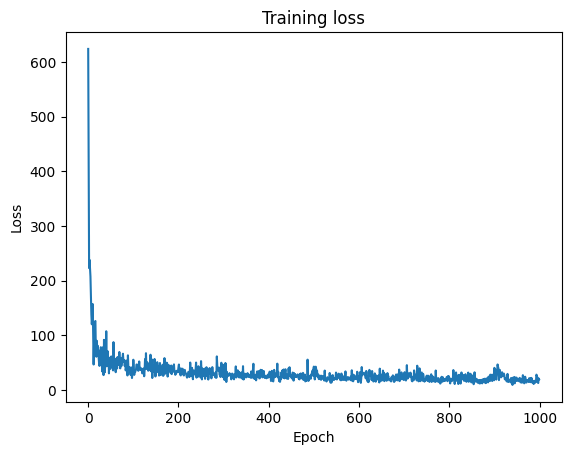

In [138]:
plt.plot(model.loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training loss")
plt.show()

<a id='2'></a>
# 3. Validation :

In [6]:
class black_scholes():
    """ 
    Forward the theorical BS price of an option
    """
    def __init__(
            self,
            S0 : float,
            T : float,
            K : float,
            r : float,
            sigma : float,
    ):
          self.S0 = S0
          self.T = T
          self.K = K
          self.r = r
          self.sigma = sigma

    def price_option(
            self
    ):
            D1 = (1/(self.sigma * np.sqrt(self.T))) * (np.log(self.S0/self.K) + (self.r + ((self.sigma)**2)/2) * self.T)
            D2 = D1 - self.sigma * np.sqrt(self.T)
            return self.S0 * norm.cdf (D1) - self.K * np.exp(-self.r * self.T) * norm.cdf (D2)

In [140]:
####################
### Check rapide ###
####################

# Black Scholes
price_bs = black_scholes(S0=100., T=1., K=100., r=0.02, sigma=0.2)

# Deep BSDE
model = training(N=10, n=100, S0=100., T=1., K=100., r=0.02, sigma=0.2, hidden_size=32, lr=1e-2, training_iterations=1_000)
model.train()
price_bsde = model.price_return()

print(f"Prix BS analytique : {price_bs.price_option():.4f}")
print(f"Prix BSDE          : {price_bsde:.4f}")

Prix BS analytique : 8.9160
Prix BSDE          : 8.8817


n = 100 N = 50 p = 5.8
n = 1000 N = 10  p = 5.9

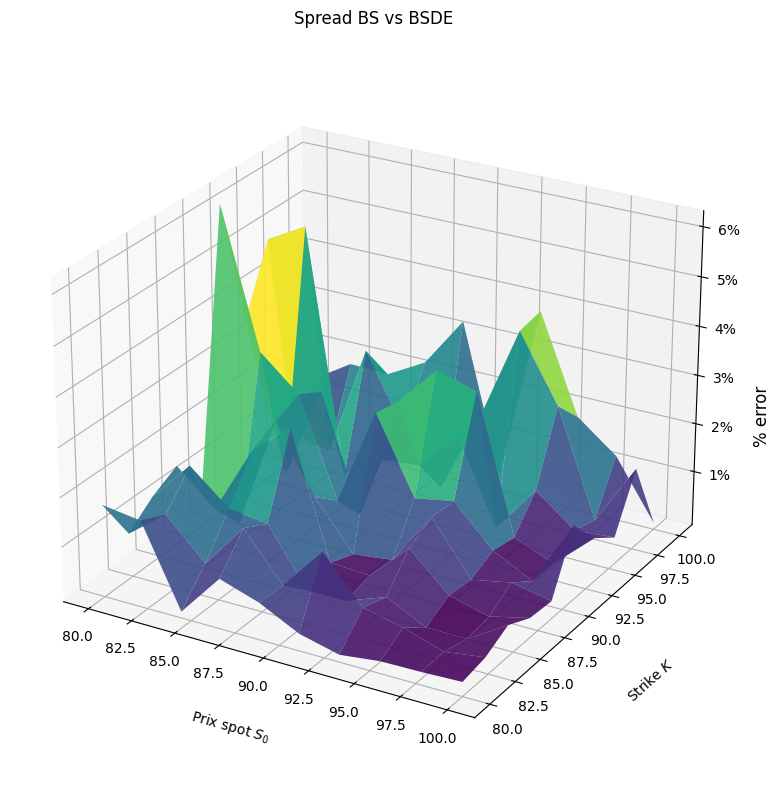

In [ ]:
####################
### Graph report ###
####################
prices = np.linspace(80, 100, 10)
strikes = np.linspace(80, 100, 10)
spread_storage = []

for x in prices:
    for y in strikes:
        price_bs = black_scholes(S0=x, T=1., K=y, r=0.02, sigma=0.2)
        # Deep BSDE
        model = training(N=10, n=100, S0=x, T=1., K=y, r=0.02, sigma=0.2, hidden_size=32, lr=1e-1, training_iterations=1_000)
        model.train()
        price_bsde = model.price_return()
        spread = np.abs(price_bs.price_option() - price_bsde) / price_bs.price_option()
        spread_storage.append([x, y, spread])

spread_storage = np.array(spread_storage)
S = spread_storage[:, 0].reshape(10, 10)
K = spread_storage[:, 1].reshape(10, 10)
Z = spread_storage[:, 2].reshape(10, 10) * 100  # → en %

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(S, K, Z, cmap='viridis', edgecolor='none', alpha=0.9)

ax.set_xlabel('Prix spot $S_0$', labelpad=15)
ax.set_ylabel('Strike $K$', labelpad=20)
ax.set_zlabel('')
ax.zaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.3g}%'))
ax.text2D(1.02, 0.5, '% error', transform=ax.transAxes,
          fontsize=12, va='center', rotation=90)

ax.set_title('Spread BS vs BSDE', pad=20)
ax.view_init(elev=25, azim=-60)

plt.tight_layout(rect=[0, 0, 0.88, 1])
plt.show()

<a id='3'></a>
# 4. Appendix :

---

<a id='3_1'></a>
### 4.1 Construction of BSDE Scheme :


#### Price PDE :

Under the risk–neutral measure $\mathbb{Q}$, the asset price satisfies:

$$
\partial_t C \;+\; r s\,\partial_s C \;+\; \tfrac12 \sigma^2 s^2\,\partial_{ss}C \;-\; r C \;=\; 0,
\qquad C(s, T)=(s-K)_+ 
$$


$$
\implies
\partial_t C(t,s) + \mathcal{L}C(t,s) = rC,
\qquad \mathcal{L} = r s\,\partial_s + \frac{1}{2}\sigma^2 s^2\,\partial_{ss}
\qquad C(s, T) = (s-K)_+
$$

Hence, in BSDE form, the driver can be identified as
$$
\boxed{
f(y)=r\,y
}
$$

$$
\implies
\partial_t C(t,s) + \mathcal{L}C(t,s) = f(C)
$$

##### Dynamics of $C$ :

Applying Itô's formula to $C(t,S_t)$ gives
$$
dC(t,S_t)
=
\partial_t C(t,S_t)\,dt
+
\partial_s C(t,S_t)\,dS_t
+
\frac{1}{2}\partial_{ss} C(t,S_t)\,d\langle S\rangle_t
=
\left(
\partial_t C
+
rS_t\,\partial_s C
+
\frac{1}{2}\sigma^2 S_t^2\,\partial_{ss} C
\right)(t,S_t)\,dt
+
\sigma S_t\,\partial_s C(t,S_t)\,dW_t.
$$

$$
\implies
dC(t,S_t)
=
\left(
\partial_t C + \mathcal{L}C
\right)(t,S_t)\,dt
+
\sigma S_t\,\partial_s C(t,S_t)\,dW_t.
$$

$$
\implies
dC(t,S_t)
=

f(C)\,dt
+
\sigma S_t\,\partial_s C(t,S_t)\,dW_t.
$$

Defining
$$
Y_t = C(t,S_t),
\qquad
Z_t = \sigma S_t\,\partial_s C(t,S_t),
$$
we finally get
$$
\boxed{
dY_t = f(Y_t)\,dt + Z_t\,dW_t,
\qquad
Y_T = (S_T-K)_+
}
$$

---

<a id='3_2'></a>
### 4.2 Neural network approximation of the control process $(Z_t)_{t \ge 0}$


We approximate the control process $(Z_t)_{t \ge 0}$ using a family of feedforward neural networks.

Let $i \in \{0,\dots,N-1\}$. For each time step $t_i$, we introduce a neural network

$$
NN_i : \mathbb{R}^2 \rightarrow \mathbb{R}
$$


More precisely, each neural network is defined as a composition of affine maps and nonlinear activation functions. Let $L \ge 1$ be the number of layers and $(m_\ell)_{\ell=0,\dots,L}$ the layer dimensions, with $m_0 = 2 \quad (t, S_t), \qquad m_L = 1 \quad (Z_t).$

The neural network $NN_i$ is defined by

$$
NN_i(x) = A_L \circ \rho \circ A_{L-1} \circ \dots \circ \rho \circ A_1(x),
\qquad x \in \mathbb{R}^2
$$

where for $\ell = 1,\dots,L$

$$
A_\ell(x) = W_\ell x + b_\ell
$$

are affine transformations with weight matrices $W_\ell$ and bias vectors $b_\ell$, and $\rho : \mathbb{R} \rightarrow \mathbb{R}$ is a nonlinear activation function applied component-wise.

The parameters of the neural network are therefore the collection $\theta_i = (W_\ell, b_\ell)_{\ell=1,\dots,L}.$

Finally we approximate

$$
Z_{t_i} \approx NN_i(t_i,S_{t_i};\theta_i).
$$